### Install new libraries

In [1]:
#!pip install ddgs trafilatura
#%pip install openai-agents


### Setup

In [2]:
import os
from dotenv import load_dotenv
import json
from pprint import pprint
from IPython.display import Image, display, Markdown
from ddgs import DDGS
import trafilatura

from agents import Agent, Runner, function_tool


# ------------------------------
# Setup
# ------------------------------

load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if OPENAI_API_KEY is None:
	raise Exception("API key is missing")

MODEL = "gpt-4.1-mini"


### Step 1: Define the Tools

In [3]:
@function_tool
def search_web(query: str):
	"""Search the web using DuckDuckGo browser. Returns 3 results."""
	ddgs = DDGS()
	results = ddgs.text(query, max_results=3)
	print(f"  \u2705 search_web: Got results for {query}")
	return json.dumps(results, indent=2)

In [4]:
@function_tool
def fetch_url(url: str):
	"""Fetch the content of a URL using trafilatura."""
	downloaded = trafilatura.fetch_url(url)
	if downloaded:
		text =  trafilatura.extract(downloaded)
		if text:
			truncated_text = text[:2000]  # Truncate to 2,000 characters
			print(f"  \u2705 fetch_url: Got text: {len(text)} chars from {url[:60]}")
			return truncated_text
	print(f"  \u274C Failed to fetch or extract text.") # For debugging
	return f"Could not extract text from {url}. Try a different source." # For LLM input feedback


### Step 2: Describe as LLM tools

In [5]:
tools = []

In [6]:
import base64
import urllib.request
from openai import OpenAI

openai_client = OpenAI()

@function_tool
def generate_image(prompt: str) -> str:
	"""Generate an image using gpt-image-1-mini and save it to a local file."""
	print(f"  🎨 generate_image prompt: {prompt[:80]}...")
	try:
		response = openai_client.images.generate(
			model="gpt-image-1-mini",
			prompt=prompt,
			size="1024x1024",
			quality="high",
			n=1
		)

		item = response.data[0]
		filename = "hero_image.png"

		# 1. Handle b64_json (Decode bytes and save locally)
		if getattr(item, "b64_json", None) and item.b64_json:
			with open(filename, "wb") as f:
				f.write(base64.b64decode(item.b64_json))
			print(f"  ✅ generate_image: Saved to {filename}")
			return f"Image generated successfully and saved locally as: {filename}"

		# 2. Handle HTTP URL (Download and save locally)
		if getattr(item, "url", None) and item.url:
			urllib.request.urlretrieve(item.url, filename)
			print(f"  ✅ generate_image: Saved to {filename}")
			return f"Image generated successfully and saved locally as: {filename}"

		return "Failed to generate image: API returned empty data."

	except Exception as e:
		print(f"  ❌ generate_image failed: {e}")
		return f"Failed to generate image: {e}"

### Step 2: The Agents

 This Agent Prompts tells the LLM who it is and how to behave. The key things:
- What its job is
- What tools it has
- What process to follow
- What output format to produce




#### Research Agent

In [7]:

RESEARCH_AGENT_PROMPT = """You are a research specialist. Your job is to research a given topic
and produce a comprehensive research brief.

You have access to two tools:
- search_web: Search the web for information
- fetch_url: Fetch and read the full content of a web page

***IMPORTANT:
After each search with search_web, you MUST first explain your reasoning:
- Which URLs look most relevant and why
- Which ones you will fetch and why
- Which ones you are skipping and why
Only AFTER writing out your reasoning should you call fetch_url.
***

Your typical process:
1. Search for the topic to find relevant sources
2. Reflect on the search results — which sources look most relevant and why?
3. Fetch the full content of the 2-3 best URLs
4. Reflect on what you have gathered. Do you have enough? Are there gaps?
5. If there are gaps, search again with a different query
6. When you have enough information from at least 3 different sources, synthesize into a research brief

You MUST gather information from at least 3 distinct sources before delivering your brief.
If you have fewer than 3 sources, keep searching.

Your research brief MUST include:
- Key facts and statistics
- Main themes and arguments from the sources
- Notable data points
- Source URLs for attribution

Until you are ready, just keep working — search, fetch, think, reflect.
Do not rush. Take time to reflect between tool calls before deciding your next step.
Not every response needs a tool call — sometimes just thinking through what you have is the right move."""

research_agent = Agent(
	name="Research Agent",
	instructions=RESEARCH_AGENT_PROMPT,
	model=MODEL,
	tools=[search_web, fetch_url]
)


#### Image Generator Agent

In [8]:
IMAGE_AGENT_PROMPT = """You are an image prompt specialist. Given a topic and content summary,
craft a detailed gpt-image-1-mini prompt for a hero image.

Call generate_image exactly ONCE with your prompt. One image only.

IMPORTANT: Return ONLY the exact filename returned by generate_image in markdown format, like: ![hero image](hero_image.png). Do NOT add prefixes like 'sandbox:/'.

Rules for your gpt-image-1-mini prompt:
- Describe a clean, abstract, futuristic concept representing innovation and technology (e.g., glowing network nodes, futuristic digital interfaces, conceptual blue light, subtle molecular structures).
- avoid triggering image safety filters.
- No text, logos, or words in the image.
- Focus on lighting, composition, futuristic mood, and abstract aesthetics.
- Keep the prompt under 100 words.

Call generate_image exactly ONCE with your prompt. One image only.

IMPORTANT: When returning the image URL, copy it EXACTLY character by character. Do not modify, shorten, or paraphrase the URL.
"""


image_agent = Agent(
	name="Image Agent",
	instructions=IMAGE_AGENT_PROMPT,
	model=MODEL,
	tools=[generate_image]
)

image_agent_as_tool = image_agent.as_tool(
	tool_name="image_agent",
	tool_description="Generate a hero image for an article based on a topic and content summary. Supply the topic and content summary."
)

### Orchestrator Agent

In [9]:
ORCHESTRATOR_AGENT_PROMPT = """You are the orchestrator of a multi-agent article writing system.
Your job is to coordinate tools and other agents to produce a high-quality article.
Use the tools available to you and/or delegate tasks to the appropriate agents.
Never do the work yourself. Always use tools or agents.
Your tools and agents are specialists and should be doing the work, you are the manager.

Deliver the selected research brief as the final output, and
include the image at the top of your final output in markdown format strictly as: ![hero image](hero_image.png)

CRITICAL: Do not add any path prefixes like 'sandbox:/' or folder names. Use 'hero_image.png' as the exact relative filename.

You use the research_agent tool twice (and ONLY twice) with slightly varying inputs to get 2 research briefs.
You pick the best research brief out of the two and deliver it as output.
Do not combine the two briefs, just pick the best one.
Do not do the research yourself or add anything, you MUST use the research_agent tool to get the briefs.

Once you have selected the best brief, you MUST use the image_agent tool to generate an image.
Use the research brief to supply the image agent with the topic and content summary it needs to generate the image.

Deliver the selected research brief as the final output, and
include the image URL at the top of your final output in markdown format like this: ![hero image](image_url)

IMPORTANT: When returning the image URL, copy it EXACTLY character by character. Do not modify, shorten, or paraphrase the URL.
"""

orchestrator_agent = Agent(
	name="Orchestrator Agent",
	model="o4-mini", ##Reasoning
	instructions=ORCHESTRATOR_AGENT_PROMPT,
	tools=[research_agent.as_tool(tool_name="research_agent", tool_description="Research a topic and return a brief with key facts, statistics, themes,  and source URLs. Pass the topic as input.", max_turns=25),
		image_agent_as_tool]
)

### Let's Run IT!

In [10]:
from agents import trace

with trace("Article Writer", group_id="Learning AI Engineering"):
	result = await Runner.run(
		orchestrator_agent,
		#input="Research the following topic and produce a comprehensive research brief: How will AI is used in healthcare 2040?",
		#input="Research the following topic and produce a comprehensive research brief: How seniors can understand AI",
		#input="Research the following topic and produce a comprehensive research brief: How to become an AI engineer",
		input="Research the following topic and produce a comprehensive research brief: How to start a side gig as an AI engineer",
		max_turns=30
	)

  ✅ search_web: Got results for how to start a side gig as an AI engineer
  ✅ fetch_url: Got text: 17144 chars from https://sidehustleschool.com/guides/ai-side-hustles/
  ✅ fetch_url: Got text: 13706 chars from https://www.layer3labs.io/guides/ai-side-hustles
  ✅ fetch_url: Got text: 15062 chars from https://www.mercor.com/resources/experts/best-ai-side-hustle
  ✅ search_web: Got results for starting a side gig as an AI engineer comprehensive guide
  ❌ Failed to fetch or extract text.
  ✅ fetch_url: Got text: 3446 chars from https://www.aigigjobs.com/getting-started
  ✅ fetch_url: Got text: 15062 chars from https://www.mercor.com/resources/experts/best-ai-side-hustle
  ✅ search_web: Got results for guide to starting a side gig as an AI engineer skills tools marketing challenges
  ✅ fetch_url: Got text: 13706 chars from https://www.layer3labs.io/guides/ai-side-hustles
  ✅ fetch_url: Got text: 11573 chars from https://www.aithemag.com/guides/make-money-with-ai/best-ai-s
  🎨 generate_imag

Agent: Orchestrator Agent
---



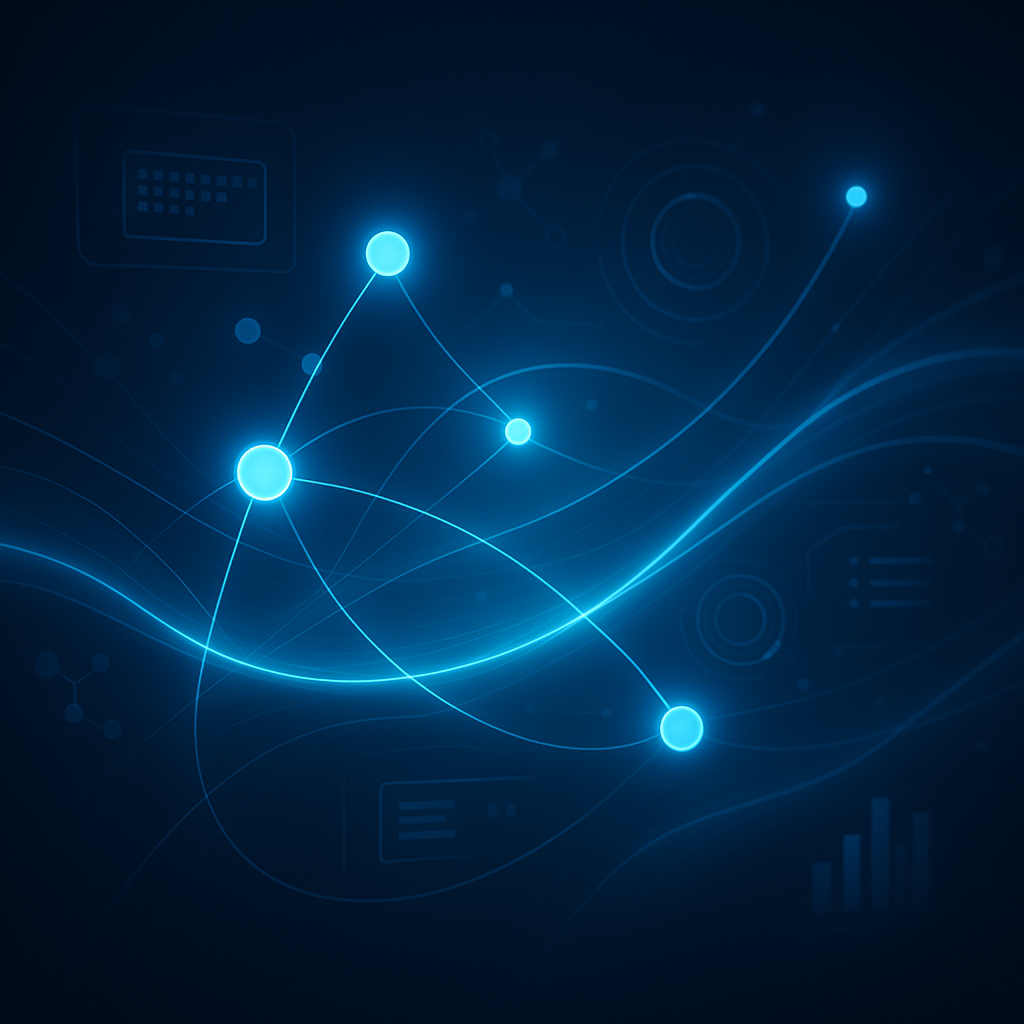



Research Brief: How to Start a Side Gig as an AI Engineer

1. Overview  
   • Definition: A side gig leverages your AI engineering skills part-time to generate income outside a primary job.  
   • Categories:  
     - Service–based hustles (freelance writing, design, video editing, automation services powered by AI)  
     - Platform–based hustles (model training, data labeling, prompt engineering for AI companies)  
     - Product–based hustles (AI-powered digital products like prompt packs, micro-courses, templates)

2. Key Facts & Statistics  
   • Time to First Dollar: Generally 2–8 weeks, depending on niche and client outreach.  
   • Startup Costs: $0–$100/month for AI tool subscriptions; optional investment in paid courses or marketing.  
   • Monthly Income Potential:  
     - Beginners: $200–$800  
     - Intermediate: $1,000–$3,000  
     - Advanced: $3,000+  
   • Success Rates: Consistent earners commit 5–10 hours/week for at least 3 months before stable income.

3. Main Themes & Strategies  
   a. AI as an Enabler, Not a Replacement  
      – AI tools boost productivity but require human oversight for quality, judgment, and domain expertise.  
   b. Validate Before You Launch  
      – Research market demand; pilot small offers or MVPs to gather feedback.  
   c. Narrow, Repeatable Niches  
      – Focus on a specific customer (e.g., small businesses, executives) and a specific deliverable (e.g., chatbot setup, LinkedIn content).  
   d. Customer Acquisition & Retention  
      – Leverage networking, referrals, content marketing, and platforms (Upwork, Fiverr).  
      – Offer subscriptions or retainers for ongoing revenue.  
   e. Scale with Products & Templates  
      – After honing a service, create digital assets (prompt libraries, templates) for passive income.

4. Typical Side Gig Examples  
   • AI-Powered Chatbots  
     – Setup fee: $250–$500; monthly support: $50–$150  
   • LinkedIn Content Packages  
     – Monthly retainer: $200–$800 for 8–12 posts  
   • Automated Book Summaries  
     – Subscription: $10–$20/month; can scale to $1,000+ monthly with 100+ subscribers

5. Common Pitfalls & How to Avoid Them  
   • Treating AI as the Product: Position your expertise, not the AI tool itself.  
   • Ignoring Client Relationships: Invest time in communication, deliver on promises, and seek referrals.  
   • Overreliance on One Platform: Diversify channels to reduce dependence on any single marketplace.

6. Actionable Next Steps  
   1. Identify Your Niche & Offer  
   2. Select AI Tools & Build Sample Work  
   3. Validate with Prospects or Pilot Clients  
   4. Set Up Profiles on Freelance Platforms  
   5. Launch, Gather Feedback, and Iterate  
   6. Develop a Scalable Product or Subscription Offer

Sources  
– Layer3Labs: “AI Side Hustles That Actually Pay”  
– Mercor: “Best AI Side Hustles to Start in 2026”  
– Side Hustle School: “How Real People Are Making Money with AI in 2026”

In [11]:
import base64
from IPython.display import Markdown, display, HTML

print(f"Agent: {result.last_agent.name}")
print("---")

# Read local image bytes and encode to base64 data URI (bypasses browser caching)
with open("hero_image.png", "rb") as f:
    img_b64 = base64.b64encode(f.read()).decode("utf-8")
img_html = f'<img src="data:image/png;base64,{img_b64}" alt="Hero Image"/>'

# Build cleaned markdown without the markdown image reference
clean_output = result.final_output.replace("sandbox:/", "")
clean_output_no_image = clean_output.replace("![hero image](hero_image.png)", "")

# Display the embedded image (HTML) and then the markdown content
display(HTML(img_html))
display(Markdown(clean_output_no_image))

In [12]:
# from IPython.display import Image, display
# import time

# print(f"Agent: {result.last_agent.name}")
# print(f"---")


# ####

# # Forces display to reload from disk rather than browser cache
# display(Image(filename='hero_image.png', data=open('hero_image.png', 'rb').read()))
# clean_output = result.final_output.replace("sandbox:/", "")
# display(Markdown(clean_output))


#### Test to generate an image of an apple and display it here in this notebook

In [13]:
# import base64
# import logging
# import os
# import sys
# from dotenv import load_dotenv
# from IPython.display import Image, display
# from openai import OpenAI

# # 1. Configure logging to stdout so step-by-step progress appears in the cell
# logging.basicConfig(
# 	level=logging.INFO,
# 	format="%(asctime)s [%(levelname)s] %(message)s",
# 	handlers=[logging.StreamHandler(sys.stdout)],
# 	force=True,  # Overrides any existing notebook logger configuration
# )
# logger = logging.getLogger("ImageTest")

# # 2. Setup API key and OpenAI client
# load_dotenv()
# api_key = os.getenv("OPENAI_API_KEY")

# if not api_key:
# 	logger.error("OPENAI_API_KEY is missing! Please check your .env file.")
# else:
# 	logger.info("Initializing OpenAI client...")
# 	client = OpenAI(api_key=api_key)

# 	# 3. Define test prompt
# 	prompt = "A simple, crisp red apple on a plain white background"
# 	logger.info(f"Sending image generation request for prompt: '{prompt}'")

# 	try:
# 		# Call the live image generation API
# 		response = client.images.generate(
# 			model="gpt-image-1-mini",
# 			prompt=prompt,
# 			size="1024x1024",
# 			quality="high",
# 			n=1,
# 		)

# 		logger.info("Received response from OpenAI API.")
# 		item = response.data[0]
# 		image_uri = None

# 		# Check if an HTTP URL was returned
# 		if getattr(item, "url", None):
# 			image_uri = item.url
# 			logger.info("  ✅ Image URL retrieved successfully!")
# 			print(f"\n--- GENERATED IMAGE URL ---\n{image_uri}\n----------------------------\n")

# 		# Check if b64_json payload was returned instead
# 		elif getattr(item, "b64_json", None):
# 			image_uri = f"data:image/png;base64,{item.b64_json}"
# 			logger.info("  ✅ Image Base64 payload retrieved successfully!")
# 			print(f"\n--- GENERATED IMAGE BASE64 DATA URI ---\n{image_uri[:100]}... (truncated)\n---------------------------------------\n")

# 		else:
# 			logger.warning("Response payload contained neither 'url' nor 'b64_json'.")

# 		# 4. Render image directly in the notebook output
# 		if image_uri:
# 			logger.info("Rendering image in notebook output...")
# 			display(Image(url=image_uri))
# 			logger.info("Image displayed successfully.")

# 	except Exception as e:
# 		logger.error(f"Image generation failed with error: {e}", exc_info=True)

In [14]:
# import base64
# import logging
# import os
# import sys
# from dotenv import load_dotenv
# from IPython.display import Image, display
# from openai import OpenAI

# # 1. Configure logging to stdout so step-by-step progress appears in the cell
# logging.basicConfig(
# 	level=logging.INFO,
# 	format="%(asctime)s [%(levelname)s] %(message)s",
# 	handlers=[logging.StreamHandler(sys.stdout)],
# 	force=True,  # Overrides any existing notebook logger configuration
# )
# logger = logging.getLogger("ImageTest")

# # 2. Setup API key and OpenAI client
# load_dotenv()
# api_key = os.getenv("OPENAI_API_KEY")

# if not api_key:
# 	logger.error("OPENAI_API_KEY is missing! Please check your .env file.")
# else:
# 	logger.info("Initializing OpenAI client...")
# 	client = OpenAI(api_key=api_key)

# 	# 3. Define the futuristic healthcare prompt
# 	prompt = (
# 		"A clean, abstract, high-tech healthcare environment in 2040. "
# 		"Futuristic medical diagnostics interface, glowing digital data visualization, "
# 		"subtle holographic human body scan, blue and teal ambient lighting, "
# 		"sleek futuristic clinical aesthetic, soft depth of field."
# 	)
# 	logger.info(f"Sending image generation request for prompt: '{prompt[:80]}...'")

# 	try:
# 		# Call the live image generation API
# 		response = client.images.generate(
# 			model="gpt-image-1-mini",
# 			prompt=prompt,
# 			size="1024x1024",
# 			quality="high",
# 			n=1,
# 		)

# 		logger.info("Received response from OpenAI API.")
# 		item = response.data[0]
# 		image_uri = None

# 		# Check if Base64 payload was returned
# 		if getattr(item, "b64_json", None):
# 			image_uri = f"data:image/png;base64,{item.b64_json}"
# 			logger.info("  ✅ Base64 payload retrieved successfully!")
# 			print(f"\n--- GENERATED IMAGE DATA URI ---\n{image_uri[:100]}... (truncated)\n---------------------------------\n")

# 		# Fallback to HTTP URL if returned
# 		elif getattr(item, "url", None):
# 			image_uri = item.url
# 			logger.info("  ✅ Image URL retrieved successfully!")
# 			print(f"\n--- GENERATED IMAGE URL ---\n{image_uri}\n----------------------------\n")

# 		else:
# 			logger.warning("Response payload contained neither 'b64_json' nor 'url'.")

# 		# 4. Render image directly in the notebook output
# 		if image_uri:
# 			logger.info("Rendering image in notebook output...")
# 			display(Image(url=image_uri))
# 			logger.info("Image displayed successfully.")

# 	except Exception as e:
# 		logger.error(f"Image generation failed with error: {e}", exc_info=True)

In [15]:
# # Diagnostic: check notebook kernel working directory and display hero_image.png
# import os
# from pathlib import Path
# from IPython.display import Image, display
# print('Kernel cwd:', os.getcwd())
# p = Path('hero_image.png')
# print('Resolved path:', p.resolve())
# print('Exists:', p.exists())
# if p.exists():
#     display(Image(filename=str(p)))
# else:
#     print('hero_image.png not found in cwd; try using absolute path or move the file into the notebook folder.')
